In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, PrecisionRecallDisplay)

# ── Load 
df = pd.read_excel(r'default of credit card clients.xls', header=1)
df.columns = df.columns.str.strip()
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})
TARGET = 'default payment next month'

# ── Feature Engineering ──────────────────────────────────────
PAY_COLS  = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
BILL_COLS = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
AMT_COLS  = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
             'PAY_AMT4','PAY_AMT5','PAY_AMT6']

# --- Fitur berbasis keterlambatan (dari heatmap: PAY_X korelasi tinggi) ---
df['TOTAL_DELAY']       = df[PAY_COLS].clip(lower=0).sum(axis=1)
df['NUM_LATE_MONTHS']   = (df[PAY_COLS] > 0).sum(axis=1)
df['MAX_DELAY']         = df[PAY_COLS].max(axis=1)
df['DELAY_TREND']       = df['PAY_0'] - df['PAY_6']
df['RECENT_ESCALATION'] = (df['PAY_0'] > df['PAY_2']).astype(int) + \
                           (df['PAY_2'] > df['PAY_3']).astype(int)

df['UTILIZATION_RATIO'] = (df['BILL_AMT1'] / df['LIMIT_BAL'].clip(lower=1)).clip(0, 2)
df['AVG_UTILIZATION']   = (df[BILL_COLS].mean(axis=1) / df['LIMIT_BAL'].clip(lower=1)).clip(0, 2)
df['HIGH_UTIL_FLAG']    = (df['UTILIZATION_RATIO'] > 0.9).astype(int)

# Berapa persen tagihan yang berhasil dibayar tiap bulan
for i in range(1, 7):
    bill = df[f'BILL_AMT{i}'].clip(lower=1)
    df[f'PAY_RATIO_{i}'] = (df[f'PAY_AMT{i}'] / bill).clip(0, 5)

PAY_RATIO_COLS = [f'PAY_RATIO_{i}' for i in range(1, 7)]
df['AVG_PAY_RATIO']     = df[PAY_RATIO_COLS].mean(axis=1)
# Apakah konsisten membayar sedikit sekali? (< 5% tagihan)
df['CHRONIC_UNDERPAY']  = (df[PAY_RATIO_COLS] < 0.05).sum(axis=1)
# Apakah total pembayaran meningkat atau menurun?
df['PAYMENT_TREND']     = df['PAY_AMT1'] - df['PAY_AMT6']
df['TOTAL_PAYMENT']     = df[AMT_COLS].sum(axis=1)
df['TOTAL_BILL']        = df[BILL_COLS].sum(axis=1)
# Payment gap: selisih total tagihan vs total bayar (semakin besar = makin bahaya)
df['PAYMENT_GAP']       = (df['TOTAL_BILL'] - df['TOTAL_PAYMENT']).clip(lower=0)

# --- Fitur stabilitas tagihan ---
# Tagihan yang naik terus = tanda tidak terkontrol
df['BILL_GROWTH']       = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_VOLATILITY']   = df[BILL_COLS].std(axis=1)

ENGINEERED_FEATURES = (
    PAY_COLS + BILL_COLS + AMT_COLS
    + ['LIMIT_BAL', 'AGE', 'SEX', 'EDUCATION', 'MARRIAGE']
    + ['TOTAL_DELAY', 'NUM_LATE_MONTHS', 'MAX_DELAY', 'DELAY_TREND',
       'RECENT_ESCALATION', 'UTILIZATION_RATIO', 'AVG_UTILIZATION',
       'HIGH_UTIL_FLAG', 'AVG_PAY_RATIO', 'CHRONIC_UNDERPAY',
       'PAYMENT_TREND', 'TOTAL_PAYMENT', 'TOTAL_BILL', 'PAYMENT_GAP',
       'BILL_GROWTH', 'BILL_VOLATILITY']
    + PAY_RATIO_COLS
)

print(f"Total fitur: {len(ENGINEERED_FEATURES)}")
print(f"Default rate: {df[TARGET].mean():.2%}")

Total fitur: 45
Default rate: 22.12%


EDA

In [55]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_RATIO_5,PAY_RATIO_6,AVG_PAY_RATIO,CHRONIC_UNDERPAY,PAYMENT_TREND,TOTAL_PAYMENT,TOTAL_BILL,PAYMENT_GAP,BILL_GROWTH,BILL_VOLATILITY
0,1,20000,2,2,1,24,2,2,-1,-1,...,0.000000,0.000000,0.037019,5,0,689,7704,7015,3913,1761.633219
1,2,120000,2,2,2,26,-1,2,0,0,...,0.000000,0.613309,0.311916,2,-2000,5000,17077,12077,-579,637.967841
2,3,90000,2,2,2,34,0,0,0,0,...,0.066899,0.321564,0.115141,0,-3482,11018,101653,90635,13690,6064.518593
3,4,50000,2,2,1,37,0,0,0,0,...,0.036914,0.033844,0.036396,6,1000,8388,231334,222946,17443,10565.793518
4,5,50000,1,2,1,57,-1,0,-1,0,...,0.035987,0.035492,1.002072,2,1321,59049,109339,50290,-10514,10668.590074


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  int64  
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  int64  
 13  BILL_AMT2                   300

In [57]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_RATIO_5,PAY_RATIO_6,AVG_PAY_RATIO,CHRONIC_UNDERPAY,PAYMENT_TREND,TOTAL_PAYMENT,TOTAL_BILL,PAYMENT_GAP,BILL_GROWTH,BILL_VOLATILITY
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,3.000000e+04,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,0.548746,0.569928,0.559964,3.150433,448.077933,3.165139e+04,2.698617e+05,2.397048e+05,12351.570500,12077.787549
std,8660.398374,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,...,1.269015,1.303416,0.709729,2.013357,21931.709545,6.082768e+04,3.795643e+05,3.616494e+05,43922.421534,20302.149149
min,1.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,0.000000,-528666.000000,0.000000e+00,-3.362590e+05,0.000000e+00,-428791.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,0.020366,0.011072,0.041582,1.000000,-390.000000,6.679750e+03,2.868800e+04,4.520750e+03,-2963.000000,1549.935213
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,0.042073,0.041504,0.098891,3.000000,500.000000,1.438300e+04,1.263110e+05,1.019230e+05,923.000000,4579.662158
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,0.221145,0.238486,1.000379,5.000000,2001.250000,3.350350e+04,3.426265e+05,3.057178e+05,19793.750000,14352.259579
max,30000.000000,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,5.000000,5.000000,5.000000,6.000000,728552.000000,3.764066e+06,5.263883e+06,4.116080e+06,708323.000000,647788.051081


default payment next month
0    23364
1     6636
Name: count, dtype: int64
  Default rate: 22.12%


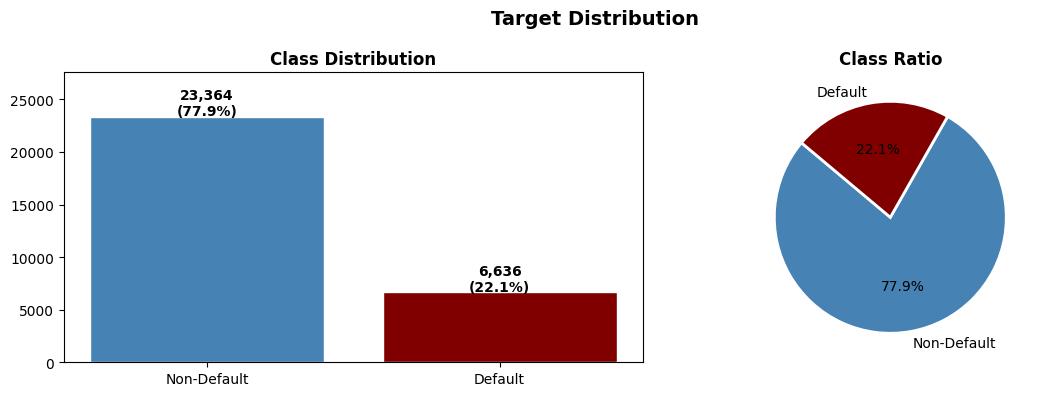

In [58]:
vc = df[TARGET].value_counts()
print(vc)
print(f"  Default rate: {df[TARGET].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Non-Default','Default'], [vc[0], vc[1]],
            color=['steelblue','maroon'], edgecolor='white')
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v + 150, f'{v:,}\n({v/len(df):.1%})',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylim(0, vc[0]*1.18)
axes[1].pie([vc[0], vc[1]], labels=['Non-Default','Default'],
            colors=['steelblue','maroon'], autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Ratio', fontweight='bold')
plt.suptitle('Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

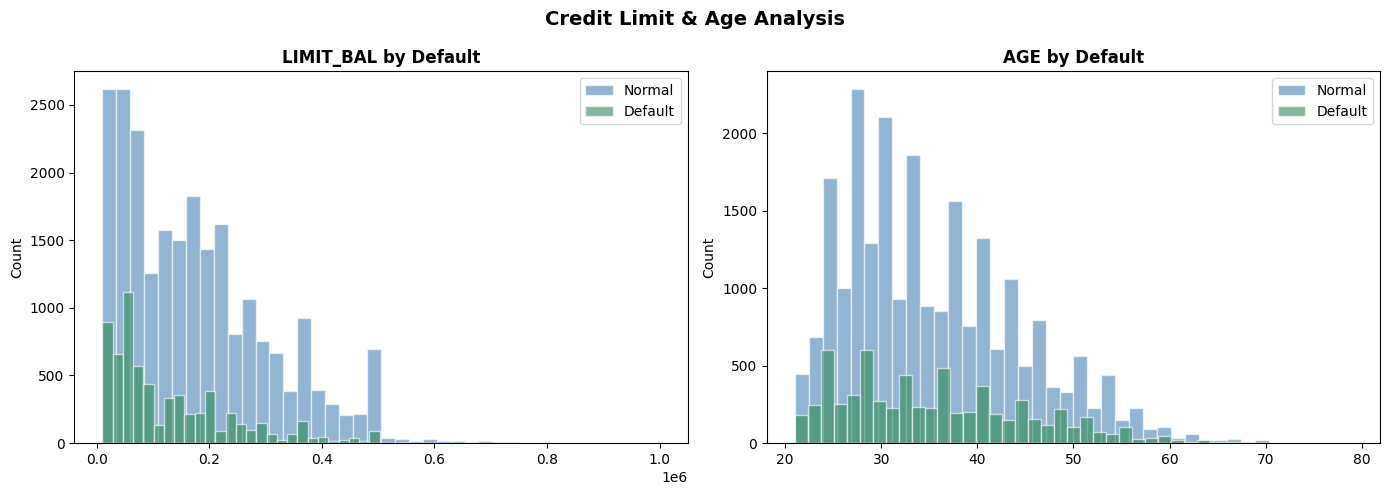

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['LIMIT_BAL','AGE']):
    for lbl, clr in [(0,'steelblue'),(1,'seagreen')]:
        ax.hist(df[df[TARGET]==lbl][col], bins=40, alpha=0.6,
                color=clr, label=f"{'Default' if lbl else 'Normal'}", edgecolor='white')
    ax.set_title(f'{col} by Default', fontweight='bold')
    ax.set_ylabel('Count'); ax.legend()
plt.suptitle('Credit Limit & Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

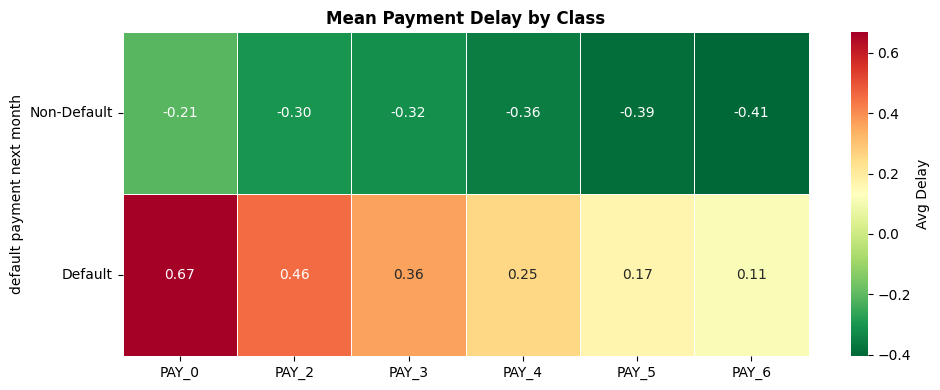

In [60]:
PAY_COLS_EDA = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
pay_heat = df.groupby(TARGET)[PAY_COLS_EDA].mean()
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pay_heat, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Delay'})
ax.set_yticklabels(['Non-Default','Default'], rotation=0)
ax.set_title('Mean Payment Delay by Class', fontweight='bold')
plt.tight_layout(); plt.show()

Preprocessing

In [61]:
# ── Step 1: Drop duplicate rows ───────────────────────────
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f"[1] Duplicate removal : {n_before - n_after} rows dropped  "
      f"({n_after:,} rows remain)")

# ── Step 2: Missing value check & fill ────────────────────
null_counts = df.isnull().sum()
null_cols   = null_counts[null_counts > 0]
if len(null_cols) == 0:
    print("[2] Missing values    : none found ✓")
else:
    print(f"[2] Missing values found:")
    print(null_cols.to_string())
    # Fill numeric with median, categorical with mode
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for c in cat_cols:
        df[c] = df[c].fillna(df[c].mode()[0])
    print("  → Filled: numeric=median, categorical=mode")

# ── Step 3: Outlier capping (IQR winsorisation) ───────────
# Applied only to continuous monetary & age columns.
# PAY_* columns are ordinal codes — do NOT cap them.
CONTINUOUS_COLS = (
    ['LIMIT_BAL', 'AGE'] +
    ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6'] +
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
)

cap_log = []
for col in CONTINUOUS_COLS:
    Q1, Q3 = df[col].quantile(0.01), df[col].quantile(0.99)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_capped = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    if n_capped > 0:
        cap_log.append((col, n_capped, lo, hi))

print(f"[3] Outlier capping   : IQR winsorisation (1st–99th pct) on {len(CONTINUOUS_COLS)} cols")
if cap_log:
    for col, n, lo, hi in cap_log:
        print(f"    {col:12s} : {n:4d} values capped  [lo={lo:,.0f}, hi={hi:,.0f}]")
else:
    print("    No values capped (data within 1.5×IQR bounds already)")

# ── Step 4: Categorical column verification ───────────────
print("[4] Categorical value check")
expected = {
    'SEX'      : {1, 2},
    'EDUCATION': {1, 2, 3, 4},
    'MARRIAGE' : {1, 2, 3},
}
for col, valid in expected.items():
    actual = set(df[col].unique())
    unexpected = actual - valid
    if unexpected:
        print(f"    ⚠  {col}: unexpected values {unexpected} → mapping to 'Others' bucket")
        if col == 'EDUCATION':
            df[col] = df[col].replace({v: 4 for v in unexpected})
        elif col == 'MARRIAGE':
            df[col] = df[col].replace({v: 3 for v in unexpected})
    else:
        print(f"    ✓  {col}: values {sorted(actual)} — all valid")

# ── Step 5: PAY_* ordinal sanity check ───────────────────
PAY_COLS_ALL = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
valid_pay    = set(range(-2, 10))
for col in PAY_COLS_ALL:
    bad = set(df[col].unique()) - valid_pay
    if bad:
        print(f"    ⚠  {col}: unexpected codes {bad}")
print(f"[5] PAY_* ordinal check: all values within expected range [-2, 9] ✓")

# ── Step 6: Data quality summary ─────────────────────────
print()
print("─" * 50)
print("PREPROCESSING SUMMARY")
print("─" * 50)
print(f"  Final shape        : {df.shape}")
print(f"  Default rate       : {df[TARGET].mean():.2%}")
print(f"  Remaining nulls    : {df.isnull().sum().sum()}")
print(f"  Remaining inf      : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")

[1] Duplicate removal : 0 rows dropped  (30,000 rows remain)
[2] Missing values    : none found ✓
[3] Outlier capping   : IQR winsorisation (1st–99th pct) on 14 cols
    BILL_AMT1    :    1 values capped  [lo=-525,369, hi=875,398]
    BILL_AMT2    :    1 values capped  [lo=-506,743, hi=844,038]
    BILL_AMT3    :    2 values capped  [lo=-488,046, hi=812,876]
    BILL_AMT4    :    1 values capped  [lo=-458,026, hi=762,811]
    BILL_AMT5    :    2 values capped  [lo=-429,383, hi=715,019]
    BILL_AMT6    :    2 values capped  [lo=-420,085, hi=699,259]
    PAY_AMT1     :   58 values capped  [lo=-99,783, hi=166,305]
    PAY_AMT2     :   61 values capped  [lo=-114,977, hi=191,628]
    PAY_AMT3     :   49 values capped  [lo=-105,000, hi=175,000]
    PAY_AMT4     :   50 values capped  [lo=-100,582, hi=167,636]
    PAY_AMT5     :   58 values capped  [lo=-98,411, hi=164,019]
    PAY_AMT6     :   39 values capped  [lo=-123,929, hi=206,548]
[4] Categorical value check
    ✓  SEX: values [np.int64

In [62]:
#splitting

# DATA SPLIT — 80% Train / 20% Test (sesuai pipeline)

X = df[ENGINEERED_FEATURES].copy()
y = df[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('='*60)
print('DATA SPLIT')
print('='*60)
print(f'Train : {X_train_raw.shape}  (default rate: {y_train.mean():.2%})')
print(f'Test  : {X_test_raw.shape}   (default rate: {y_test.mean():.2%})')


DATA SPLIT
Train : (24000, 45)  (default rate: 22.12%)
Test  : (6000, 45)   (default rate: 22.12%)


Top 15 fitur paling korelasi ke target:
NUM_LATE_MONTHS      0.4010
TOTAL_DELAY          0.3778
MAX_DELAY            0.3357
PAY_0                0.3277
PAY_2                0.2655
PAY_3                0.2389
PAY_4                0.2201
PAY_5                0.2033
PAY_6                0.1887
RECENT_ESCALATION    0.1867
LIMIT_BAL            0.1610
DELAY_TREND          0.1306
AVG_PAY_RATIO        0.1280
AVG_UTILIZATION      0.1203
CHRONIC_UNDERPAY     0.1164
Name: default payment next month, dtype: float64

Bottom 10 fitur paling noise:
BILL_AMT1        0.0227
BILL_AMT3        0.0183
BILL_AMT2        0.0180
TOTAL_BILL       0.0163
BILL_AMT4        0.0137
AGE              0.0128
PAYMENT_TREND    0.0109
BILL_AMT5        0.0096
BILL_AMT6        0.0081
PAYMENT_GAP      0.0012
Name: default payment next month, dtype: float64


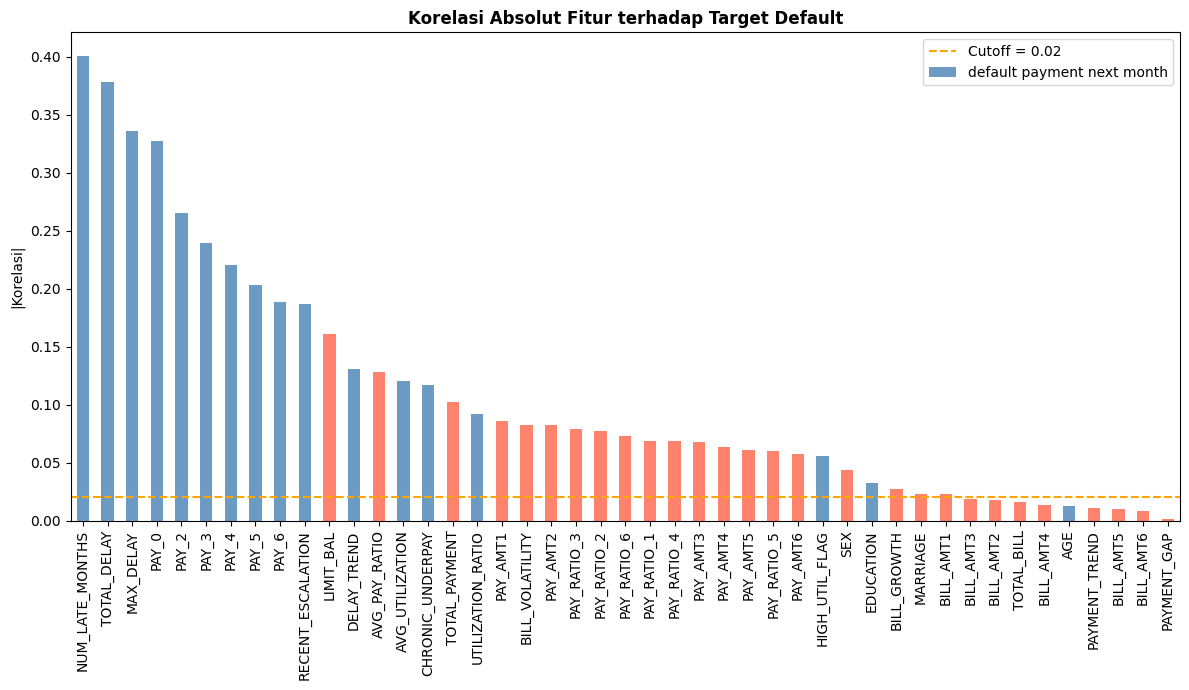

Total fitur awal   : 45
Fitur dipakai      : 31 (target: ~35)
Fitur dibuang      : 14
Dibuang            : ['SEX', 'EDUCATION', 'BILL_GROWTH', 'MARRIAGE', 'BILL_AMT1', 'BILL_AMT3', 'BILL_AMT2', 'TOTAL_BILL', 'BILL_AMT4', 'AGE', 'PAYMENT_TREND', 'BILL_AMT5', 'BILL_AMT6', 'PAYMENT_GAP']
Feature selection + scaling selesai!
Train shape: (24000, 31)
Test  shape: (6000, 31)


In [63]:
#feature selection
# Strategi: korelasi fitur terhadap target + cek redundansi antar fitur.
# Fitur yang korelasi ~0 ke target = noise murni untuk anomaly detector.

# Hitung korelasi pada TRAIN SET ONLY (fix leakage)
train_df_for_corr = X_train_raw.copy()
train_df_for_corr[TARGET] = y_train.values

corr_with_target = train_df_for_corr.corr()[TARGET].drop(TARGET)
corr_abs         = corr_with_target.abs().sort_values(ascending=False)

print("Top 15 fitur paling korelasi ke target:")
print(corr_abs.head(15).round(4))
print(f"\nBottom 10 fitur paling noise:")
print(corr_abs.tail(10).round(4))

# Plot
plt.figure(figsize=(12, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_with_target[corr_abs.index]]
corr_abs.plot(kind='bar', color=colors, alpha=0.8)
plt.axhline(0.02, color='orange', linestyle='--', linewidth=1.5, label='Cutoff = 0.02')
plt.title('Korelasi Absolut Fitur terhadap Target Default', fontweight='bold')
plt.ylabel('|Korelasi|')
plt.legend(); plt.tight_layout(); plt.show()

# Buang fitur dengan |korelasi| < 0.01 (hampir nol = noise)
CORR_CUTOFF       = 0.05
SELECTED_FEATURES = corr_abs[corr_abs >= CORR_CUTOFF].index.tolist()
DROPPED_FEATURES  = corr_abs[corr_abs <  CORR_CUTOFF].index.tolist()

print(f'Total fitur awal   : {len(ENGINEERED_FEATURES)}')
print(f'Fitur dipakai      : {len(SELECTED_FEATURES)} (target: ~35)')
print(f'Fitur dibuang      : {len(DROPPED_FEATURES)}')
print(f'Dibuang            : {DROPPED_FEATURES}')

# Apply selection & scale
X_train_sel = X_train_raw[SELECTED_FEATURES]
X_test_sel  = X_test_raw[SELECTED_FEATURES]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc  = scaler.transform(X_test_sel)

print('Feature selection + scaling selesai!')
print(f'Train shape: {X_train_sc.shape}')
print(f'Test  shape: {X_test_sc.shape}')

In [70]:
# ============================================================
# CELL 13 — IF + PCA-LOF TRAINING (IMPROVED)
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

print("\n" + "=" * 70)
print("TRAINING IF + PCA-LOF (Anomaly Detection)")
print("=" * 70)

# ============================================================
# CONTAMINATION
# ============================================================

CONTAMINATION = y_train.mean()

print(f"Contamination : {CONTAMINATION:.4f}")

# ============================================================
# TRAIN ONLY ON NORMAL CLASS
# ============================================================

X_train_normal_sc = X_train_sc[y_train == 0]

print(f"Training normal-only samples : {len(X_train_normal_sc)}")

# ============================================================
# ISOLATION FOREST
# ============================================================

iso_forest = IsolationForest(

    n_estimators=500,

    max_samples=512,

    bootstrap=False,

    contamination=CONTAMINATION,

    random_state=42,

    n_jobs=-1
)

iso_forest.fit(X_train_normal_sc)

print("✓ Isolation Forest trained")

# ============================================================
# PCA FOR LOF ONLY
# ============================================================

pca = PCA(

    n_components=0.95,

    random_state=42
)

# Fit PCA ONLY on normal train data
X_train_normal_pca = pca.fit_transform(
    X_train_normal_sc
)

# Transform full datasets
X_train_pca = pca.transform(X_train_sc)

X_test_pca = pca.transform(X_test_sc)

print(f"\nPCA dimension reduction:")
print(f"Original features : {X_train_sc.shape[1]}")
print(f"PCA features      : {X_train_pca.shape[1]}")

# ============================================================
# LOCAL OUTLIER FACTOR
# ============================================================

lof = LocalOutlierFactor(

    n_neighbors=45,

    contamination=CONTAMINATION,

    metric='euclidean',

    novelty=True,

    n_jobs=-1
)

lof.fit(X_train_normal_pca)

print("LOF trained")

# ============================================================
# NORMALIZATION FUNCTION
# ============================================================

def minmax_norm(train_arr, query_arr):

    min_v = train_arr.min()

    max_v = train_arr.max()

    return (
        (query_arr - min_v)
        / (max_v - min_v + 1e-9)
    )

# ============================================================
# ANOMALY SCORES
# ============================================================

# ---------- Isolation Forest ----------
iso_train_raw = -iso_forest.score_samples(
    X_train_sc
)

iso_test_raw = -iso_forest.score_samples(
    X_test_sc
)

# ---------- PCA-LOF ----------
lof_train_raw = -lof.score_samples(
    X_train_pca
)

lof_test_raw = -lof.score_samples(
    X_test_pca
)

# ============================================================
# NORMALIZATION
# ============================================================

iso_train = minmax_norm(
    iso_train_raw,
    iso_train_raw
)

iso_test = minmax_norm(
    iso_train_raw,
    iso_test_raw
)

lof_train = minmax_norm(
    lof_train_raw,
    lof_train_raw
)

lof_test = minmax_norm(
    lof_train_raw,
    lof_test_raw
)

# ============================================================
# SCORE SEPARATION ANALYSIS
# ============================================================

print("\nANOMALY SCORE STATISTICS")
print("-" * 50)

print(
    f"IF  Normal Mean   : "
    f"{iso_test[y_test==0].mean():.4f}"
)

print(
    f"IF  Default Mean  : "
    f"{iso_test[y_test==1].mean():.4f}"
)

print(
    f"IF  Difference    : "
    f"{(iso_test[y_test==1].mean() - iso_test[y_test==0].mean()):.4f}"
)

print("-" * 50)

print(
    f"LOF Normal Mean   : "
    f"{lof_test[y_test==0].mean():.4f}"
)

print(
    f"LOF Default Mean  : "
    f"{lof_test[y_test==1].mean():.4f}"
)

print(
    f"LOF Difference    : "
    f"{(lof_test[y_test==1].mean() - lof_test[y_test==0].mean()):.4f}"
)

print("\n✓ IF + LOF pipeline completed")


TRAINING IF + PCA-LOF (Anomaly Detection)
Contamination : 0.2212
Training normal-only samples : 18691
✓ Isolation Forest trained

PCA dimension reduction:
Original features : 31
PCA features      : 20
LOF trained

ANOMALY SCORE STATISTICS
--------------------------------------------------
IF  Normal Mean   : 0.1954
IF  Default Mean  : 0.2690
IF  Difference    : 0.0736
--------------------------------------------------
LOF Normal Mean   : 0.0207
LOF Default Mean  : 0.0242
LOF Difference    : 0.0035

✓ IF + LOF pipeline completed


In [71]:
# CELL 14 — Weight Search (fixed)
print('='*60)
print('WEIGHT SEARCH: IF vs LOF (TRAIN only — no leakage)')
print('='*60)

# Grid search on TRAIN set only
results = []
for w_iso in np.arange(0.0, 1.01, 0.05):
    w_lof = 1.0 - w_iso
    score_train = w_iso * iso_train + w_lof * lof_train
    prec, rec, thr = precision_recall_curve(y_train, score_train)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx = np.argmax(f1s)
    results.append({
        'w_iso': w_iso, 'w_lof': w_lof,
        'threshold': thr[best_idx],
        'f1': f1s[best_idx],
        'recall': rec[best_idx],
        'precision': prec[best_idx]
    })

df_results = pd.DataFrame(results).sort_values('f1', ascending=False)
best = df_results.iloc[0]

W_ISO     = best['w_iso']
W_LOF     = best['w_lof']
THRESHOLD = best['threshold']

print(f'W_ISO     : {W_ISO:.2f}')
print(f'W_LOF     : {W_LOF:.2f}')
print(f'Threshold : {THRESHOLD:.4f}  (from TRAIN PR curve)')
print(f'F1 (train): {best["f1"]:.4f}')

# Save BOTH train and test ensemble scores for Cell 17
ensemble_score_train = W_ISO * iso_train + W_LOF * lof_train
ensemble_score_test  = W_ISO * iso_test  + W_LOF * lof_test

y_pred_anom = (ensemble_score_test >= THRESHOLD).astype(int)
print('✓ Anomaly scores ready (ensemble_score_train + ensemble_score_test saved)')

WEIGHT SEARCH: IF vs LOF (TRAIN only — no leakage)
W_ISO     : 1.00
W_LOF     : 0.00
Threshold : 0.1822  (from TRAIN PR curve)
F1 (train): 0.4191
✓ Anomaly scores ready (ensemble_score_train + ensemble_score_test saved)


In [84]:
# ============================================================
# TRAIN XGBOOST
# ============================================================

from xgboost import XGBClassifier

print("\n" + "=" * 70)
print("TRAINING XGBOOST (SUPERVISED)")
print("=" * 70)

# ============================================================
# CLASS IMBALANCE
# ============================================================

scale_pos = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print(f"scale_pos_weight : {scale_pos:.2f}")

# ============================================================
# BUILD MODEL
# ============================================================

xgb_model = XGBClassifier(

    n_estimators=700,
    max_depth=5,

    learning_rate=0.03,

    subsample=0.90,
    colsample_bytree=0.90,

    min_child_weight=3,
    gamma=0.2,

    reg_alpha=0.05,
    reg_lambda=1.2,

    scale_pos_weight=scale_pos,

    objective='binary:logistic',
    eval_metric='auc',

    random_state=42,
    n_jobs=-1
)

# ============================================================
# TRAIN MODEL
# ============================================================

xgb_model.fit(
    X_train_sc,
    y_train,
    verbose=False
)

print("✓ XGBoost trained")

# ============================================================
# PROBABILITIES
# ============================================================

y_prob_xgb_train = xgb_model.predict_proba(
    X_train_sc
)[:, 1]

y_prob_xgb_test = xgb_model.predict_proba(
    X_test_sc
)[:, 1]

# ============================================================
# FIXED THRESHOLD
# ============================================================

XGB_THRESHOLD = 0.40

y_pred_xgb = (
    y_prob_xgb_test >= XGB_THRESHOLD
).astype(int)

print(f"Using fixed threshold: {XGB_THRESHOLD:.2f}")


TRAINING XGBOOST (SUPERVISED)
scale_pos_weight : 3.52
✓ XGBoost trained
Using fixed threshold: 0.40


XGBOOST FEATURE IMPORTANCE
              Feature  Importance
0     NUM_LATE_MONTHS    0.287659
2           MAX_DELAY    0.237929
1         TOTAL_DELAY    0.096141
3               PAY_0    0.079641
30     HIGH_UTIL_FLAG    0.041916
16  UTILIZATION_RATIO    0.013328
15      TOTAL_PAYMENT    0.013136
18    BILL_VOLATILITY    0.012315
4               PAY_2    0.011684
19           PAY_AMT2    0.011445
10          LIMIT_BAL    0.011392
6               PAY_4    0.010593
17           PAY_AMT1    0.010329
20        PAY_RATIO_3    0.009963
25           PAY_AMT3    0.009857
13    AVG_UTILIZATION    0.009633
12      AVG_PAY_RATIO    0.009470
11        DELAY_TREND    0.009456
24        PAY_RATIO_4    0.009317
23        PAY_RATIO_1    0.009267


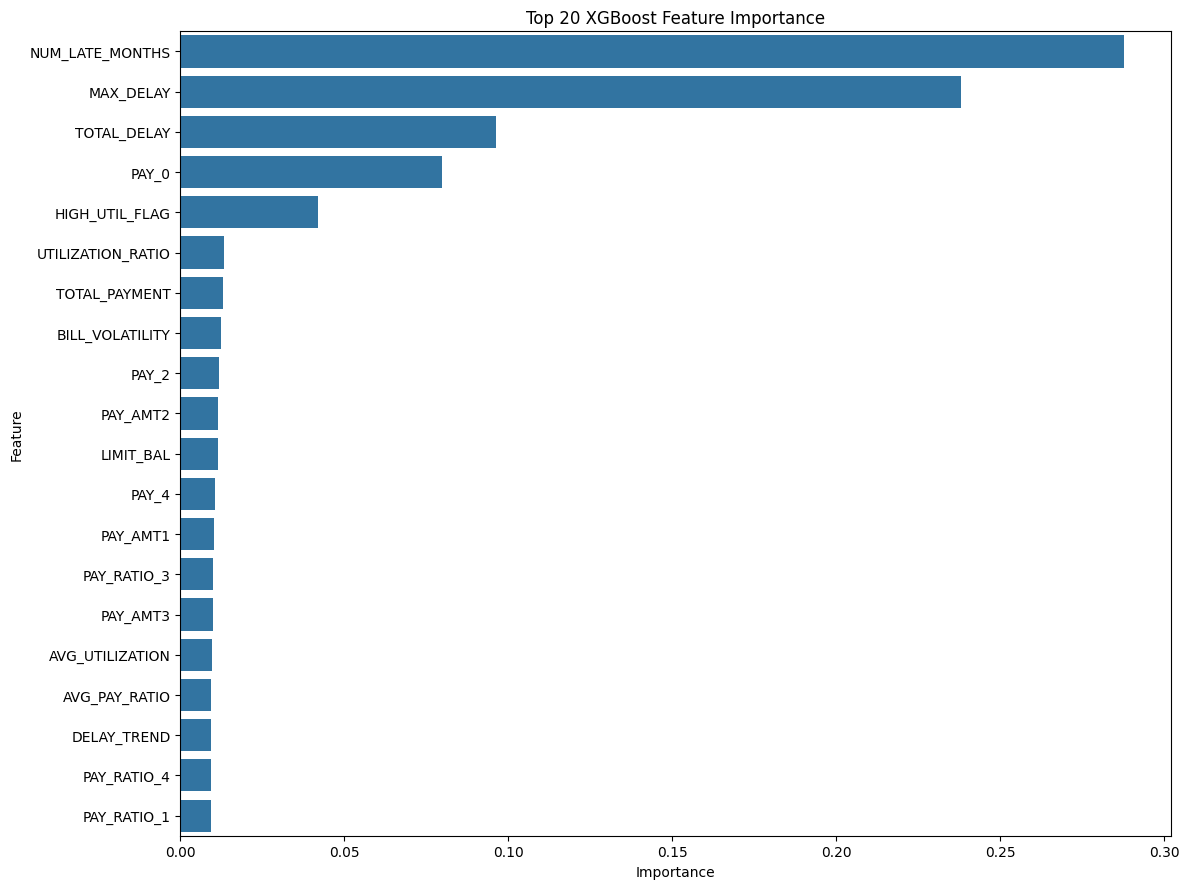

In [85]:
#XG feature importance

print('='*60)
print('XGBOOST FEATURE IMPORTANCE')
print('='*60)

importance = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(20))

plt.figure(figsize=(12, 9))
sns.barplot(data=importance.head(20), x='Importance', y='Feature')
plt.title('Top 20 XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [86]:
# ============================================================
# CELL 7: BLEND ENSEMBLE (FUSION)
# ============================================================
print("\n" + "=" * 70)
print("BLEND ENSEMBLE (Anomaly + XGBoost)")
print("=" * 70)

# ensemble_score_train and ensemble_score_test are guaranteed to exist from Cell 14

best_f1_blend = 0
ALPHA = 0.10          # floor: blend always contributes at least 10% anomaly signal
BLEND_THRESHOLD = 0.5

# 1. OPTIMASI DI TRAIN SET — alpha search with minimum floor of 0.05
for alpha in np.arange(0.10, 0.51, 0.05):   # floor=0.05 ensures blend != pure XGBoost
    blend_prob_train = alpha * ensemble_score_train + (1 - alpha) * y_prob_xgb_train

    prec, rec, thr = precision_recall_curve(y_train, blend_prob_train)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx = np.argmax(f1s)

    if f1s[best_idx] > best_f1_blend:
        best_f1_blend = f1s[best_idx]
        ALPHA = alpha
        BLEND_THRESHOLD = thr[best_idx]

print(f"Optimal α (Anomaly Weight) : {ALPHA:.2f}")
print(f"Optimal Blend Threshold    : {BLEND_THRESHOLD:.4f}")
print(f"Best Train F1-Score        : {best_f1_blend:.4f}")

# 2. APLIKASI KE TEST SET
blend_score_test = ALPHA * ensemble_score_test + (1 - ALPHA) * y_prob_xgb_test
y_pred_blend = (blend_score_test >= BLEND_THRESHOLD).astype(int)

print("✓ Blend predictions ready.")



BLEND ENSEMBLE (Anomaly + XGBoost)
Optimal α (Anomaly Weight) : 0.10
Optimal Blend Threshold    : 0.5046
Best Train F1-Score        : 0.6835
✓ Blend predictions ready.



1. IF+LOF Ensemble (Anomaly)
TN=2345 | FP=2328
FN=373 | TP=954

              precision    recall  f1-score   support

      Normal       0.86      0.50      0.63      4673
     Default       0.29      0.72      0.41      1327

    accuracy                           0.55      6000
   macro avg       0.58      0.61      0.52      6000
weighted avg       0.74      0.55      0.59      6000

Recall            : 0.7189
Precision         : 0.2907
F1-Score          : 0.4140
AUC-ROC           : 0.6409

2. XGBoost (Supervised)
TN=3206 | FP=1467
FN=389 | TP=938

              precision    recall  f1-score   support

      Normal       0.89      0.69      0.78      4673
     Default       0.39      0.71      0.50      1327

    accuracy                           0.69      6000
   macro avg       0.64      0.70      0.64      6000
weighted avg       0.78      0.69      0.72      6000

Recall            : 0.7069
Precision         : 0.3900
F1-Score          : 0.5027
AUC-ROC           : 0.7728

3. B

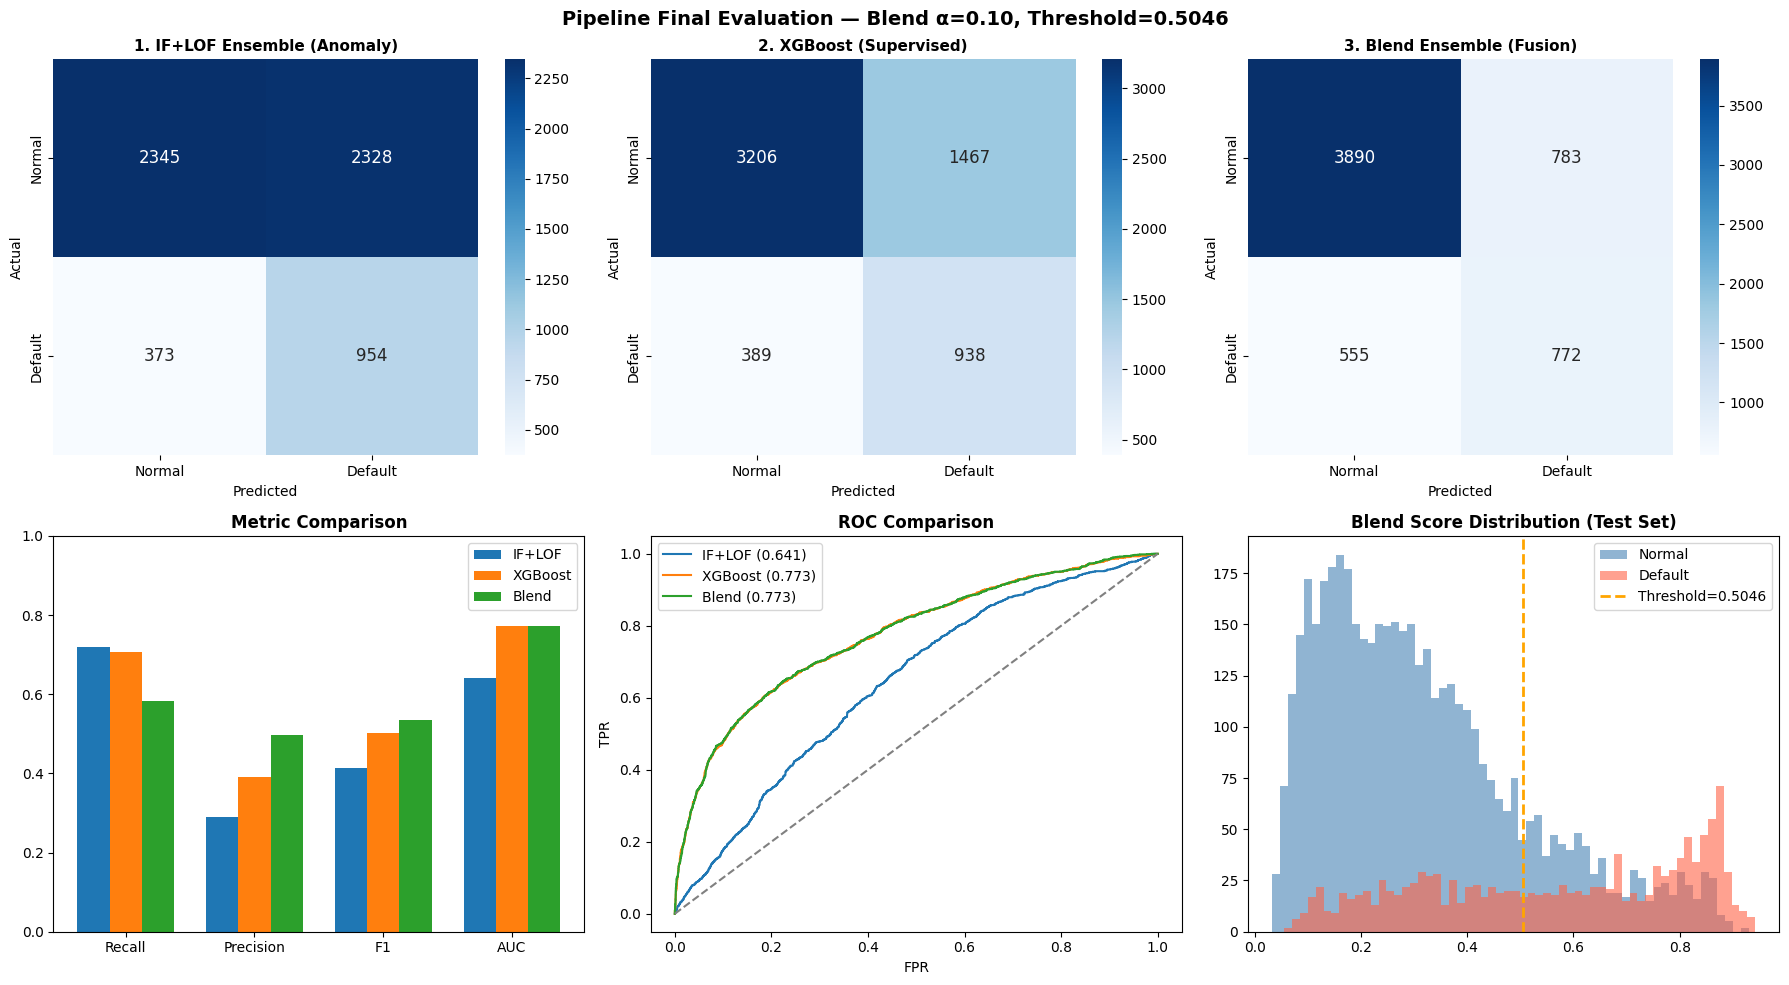

In [87]:
# ============================================================
# CELL 8: EVALUATION & VISUALIZATIONS
# ============================================================
def evaluate_model(name, y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = recall_score(y_true, y_pred, zero_division=0)
    precision = tp / (tp + fp + 1e-9)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    auc       = roc_auc_score(y_true, y_score)
   
    print('\n' + '='*65)
    print(name)
    print('='*65)
    print(f'TN={tn} | FP={fp}')
    print(f'FN={fn} | TP={tp}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Default'], zero_division=0))
    print(f'Recall            : {recall:.4f}')
    print(f'Precision         : {precision:.4f}')
    print(f'F1-Score          : {f1:.4f}')
    print(f'AUC-ROC           : {auc:.4f}')
    return {'Model': name, 'Recall': recall, 'Precision': precision,
            'F1': f1, 'AUC': auc, 'CM': cm}

res_anom  = evaluate_model('1. IF+LOF Ensemble (Anomaly)', y_test, y_pred_anom, ensemble_score_test)
res_xgb   = evaluate_model('2. XGBoost (Supervised)',     y_test, y_pred_xgb,  y_prob_xgb_test)
res_blend = evaluate_model('3. Blend Ensemble (Fusion)',  y_test, y_pred_blend, blend_score_test)

# ── Comparison Table ─────────────────────────────────────────
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'CM'}
    for r in [res_anom, res_xgb, res_blend]
])
print('\n' + '='*65)
print('FINAL MODEL COMPARISON')
print('='*65)
print(comparison.round(4).to_string(index=False))

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, res in enumerate([res_anom, res_xgb, res_blend]):
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap='Blues', ax=axes[0, i],
                xticklabels=['Normal', 'Default'], yticklabels=['Normal', 'Default'],
                annot_kws={'size': 12})
    axes[0, i].set_title(res['Model'], fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('Actual'); axes[0, i].set_xlabel('Predicted')

metrics  = ['Recall', 'Precision', 'F1', 'AUC']
x        = np.arange(len(metrics))
width    = 0.25
models_r = [res_anom, res_xgb, res_blend]
labels   = ['IF+LOF', 'XGBoost', 'Blend']
offsets  = [-width, 0, width]

for res, lbl, off in zip(models_r, labels, offsets):
    axes[1, 0].bar(x + off, [res[m] for m in metrics], width, label=lbl)
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend(); axes[1, 0].set_ylim(0, 1); axes[1, 0].set_title('Metric Comparison', fontweight='bold')

fpr_a, tpr_a, _ = roc_curve(y_test, ensemble_score_test)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb_test)
fpr_b, tpr_b, _ = roc_curve(y_test, blend_score_test)
axes[1, 1].plot(fpr_a, tpr_a, label=f'IF+LOF ({res_anom["AUC"]:.3f})')
axes[1, 1].plot(fpr_x, tpr_x, label=f'XGBoost ({res_xgb["AUC"]:.3f})')
axes[1, 1].plot(fpr_b, tpr_b, label=f'Blend ({res_blend["AUC"]:.3f})')
axes[1, 1].plot([0,1],[0,1],'--', color='gray')
axes[1, 1].legend(); axes[1, 1].set_title('ROC Comparison', fontweight='bold')
axes[1, 1].set_xlabel('FPR'); axes[1, 1].set_ylabel('TPR')

axes[1, 2].hist(blend_score_test[y_test==0], bins=60, alpha=0.6, label='Normal', color='steelblue')
axes[1, 2].hist(blend_score_test[y_test==1], bins=60, alpha=0.6, label='Default', color='tomato')
axes[1, 2].axvline(BLEND_THRESHOLD, linestyle='--', color='orange', linewidth=2,
                   label=f'Threshold={BLEND_THRESHOLD:.4f}')
axes[1, 2].legend(); axes[1, 2].set_title('Blend Score Distribution (Test Set)', fontweight='bold')

plt.suptitle(f'Pipeline Final Evaluation — Blend α={ALPHA:.2f}, Threshold={BLEND_THRESHOLD:.4f}',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()